# Track A — Signal Selection & Model Training

Signal selection, risk modelling and robustness work for Track A, following on from
`data-analysis.ipynb`. The sections below correspond to Questions 11–34 of
`RESEARCH_LOG.md`; Part 6 of that file lists the decisions already hardcoded in
`src/`, and this notebook re-derives them.

The main tool is `src/research/signal_eval.py` — `information_coefficient`,
`ic_summary`, `fama_macbeth`, `spread_portfolio` and `compare_signals`. Each section
states what is being measured, runs it, then records what the result implies.

### Setup

Imports, the panel load, and the signal build. `build_signals(panel)` returns the
three candidates registered in `SIGNAL_LIBRARY` in `src/utils/signals.py`.

In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

root_dir = os.path.abspath(os.path.join(os.getcwd(), '../..'))
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.utils.data import load_panel
from src.utils.signals import build_signals

panel = load_panel()
signals_dict = build_signals(panel)

print("Signal Keys Returned:")
for key in signals_dict.keys():
    print(f" - {key}")

Signal Keys Returned:
 - MOM_12_1
 - VOLADJ_MOM_12_1
 - ST_REV_21


Three signals come back: `MOM_12_1` (12-1 momentum), `VOLADJ_MOM_12_1` (the same
momentum divided by trailing volatility) and `ST_REV_21` (21-day short-term reversal).

## 1. The three candidates

* **Economic stories — why each *should* predict returns:**
  1. **`MOM_12_1` (medium-term momentum):** behavioural underreaction and slow news diffusion. Information spreads through a cross-section gradually, so a name that has outperformed over the past year tends to keep outperforming over the next month.
  2. **`VOLADJ_MOM_12_1` (volatility-scaled momentum):** the same story, with the trailing return divided by trailing volatility. Per the docstring in `src/utils/signals.py`, a high-volatility name can post a large trailing return from noise alone, so scaling by vol is meant to separate trend from noise and align the ranking with volatility-based position sizing.
  3. **`ST_REV_21` (short-term reversal):** liquidity provision. Market-maker inventory imbalances and temporary over-reaction to idiosyncratic news push prices away from fair value over roughly a month, and the correction is the return being harvested.

* **Why `momentum_12_1` skips the most recent 21 days:** without the skip, the momentum window would overlap the short-term reversal horizon, which works in the *opposite* direction over that month, along with bid-ask bounce and other microstructure noise. The skip stops the two effects from partially cancelling inside one signal.

* **The falsification control:** one of the three was included as a control rather than a candidate — a signal expected to *fail*, so that a pipeline bug, a look-ahead leak or a data-snooping artefact would announce itself by the control passing. Which one it is, and what happened to it, is settled by the evidence in Section 3 rather than asserted here.

## 2. No look-ahead

`assert_causal(panel)` rebuilds every signal on truncated panels and demands an exact
match against the corresponding full-sample row. Any signal reading data after its
as-of date fails that comparison.

In [2]:
from src.utils import signals as SG
from src.utils.signals import assert_causal

# 1. The real signals must reproduce exactly when rebuilt on truncated panels.
checks = assert_causal(panel)
print(f"Clean signals pass: {len(checks)} point-in-time checks, "
      f"max deviation {checks['max_abs_diff'].max():.1e}")

# 2. A guard that has never been shown to fire is not evidence. Plant two signals
#    that genuinely cheat and confirm each one is caught.
planted = {
    "LEAKY":   lambda p: p.log_returns.shift(-1).rolling(20, min_periods=10).sum(),
    "CENTRED": lambda p: p.log_returns.rolling(41, center=True, min_periods=20).mean(),
}
for name, fn in planted.items():
    SG.SIGNAL_LIBRARY[name] = fn
    try:
        assert_causal(panel, names=[name])
        print(f"  NOT DETECTED: planted leak {name!r} passed the guard")
    except AssertionError:
        print(f"  Detected: planted leak {name!r} rejected by assert_causal")
    finally:
        del SG.SIGNAL_LIBRARY[name]

Clean signals pass: 18 point-in-time checks, max deviation 0.0e+00
  Detected: planted leak 'LEAKY' rejected by assert_causal
  Detected: planted leak 'CENTRED' rejected by assert_causal


* **(The guard passes.)** 18 point-in-time checks across the three signals reproduce the full-sample rows at **zero** deviation — no signal in `SIGNAL_LIBRARY` uses information unavailable at its as-of date. This matters more than usual here, because Section 3 finds that the signal expected to fail is the one that works, and the first alternative explanation for that is a leak.

* **(And the guard fires.)** A check that has never rejected anything is not evidence. Two signals that genuinely cheat are planted into `SIGNAL_LIBRARY` and both are caught: `LEAKY`, which reads tomorrow's return through `.shift(-1)`, and `CENTRED`, which uses a 41-day centred window straddling the as-of date. Each is removed again in a `finally` block, so the library is unchanged afterwards. The clean result in the first bullet is therefore a pass on a test that can fail.

## 3. Does the ranking predict returns?

`compare_signals` computes the Information Coefficient for all three signals at
horizons of 1, 5 and 21 days with Newey-West corrected t-statistics, and pairs it with
a Fama-MacBeth regression and a naive spread-portfolio summary. Forward returns are
open-to-open from $t+1$.

In [3]:
from src.research.signal_eval import compare_signals

ic_results = compare_signals(panel, horizons = [1,5,21])
display(ic_results)

(                               ic_mean    ic_std     ic_ir  ic_tstat_nw  \
 signal          horizon_days                                              
 MOM_12_1        1             0.016619  0.266862  0.062276     2.205311   
                 5             0.021163  0.291932  0.072491     1.231204   
                 21            0.026365  0.310131  0.085012     0.872991   
 ST_REV_21       1             0.020432  0.271616  0.075225     2.998186   
                 5             0.023906  0.268131  0.089159     1.781444   
                 21            0.071305  0.244266  0.291917     3.641988   
 VOLADJ_MOM_12_1 1             0.021300  0.261880  0.081336     2.854817   
                 5             0.025313  0.287919  0.087917     1.466048   
                 21            0.028497  0.310028  0.091918     0.954036   
 
                               ic_pvalue  ic_hit_rate  ic_n_dates  \
 signal          horizon_days                                       
 MOM_12_1        1      

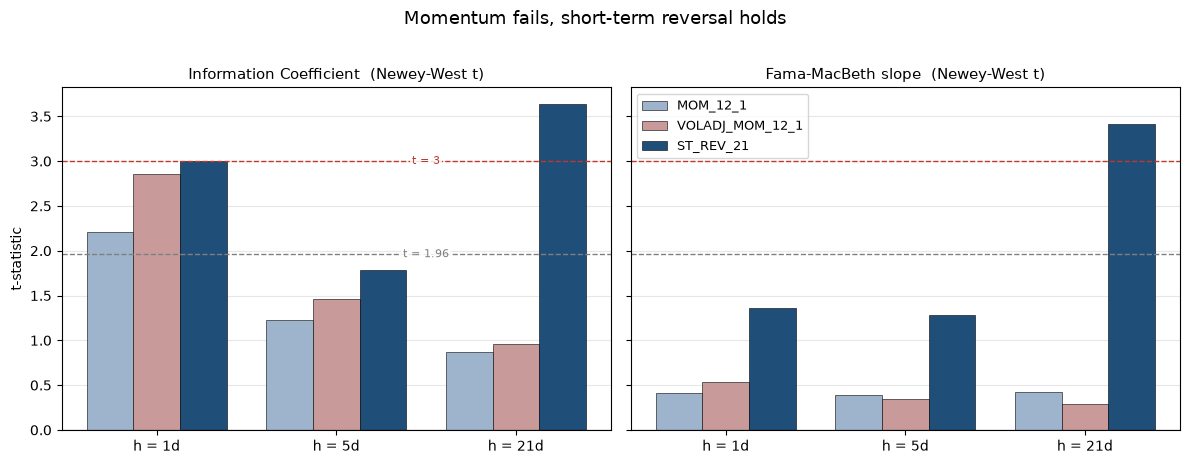

In [4]:
import os

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# One palette for every figure in this notebook, so the report's exhibits read as a set.
PALETTE = {"MOM_12_1": "#9db4cc", "VOLADJ_MOM_12_1": "#c89a9a", "ST_REV_21": "#1f4e79"}
ACCENT, INK = "#c0392b", "#1f4e79"

ic_table = ic_results[0]
horizons = [1, 5, 21]
signal_order = ["MOM_12_1", "VOLADJ_MOM_12_1", "ST_REV_21"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
width, x = 0.26, np.arange(len(horizons))

for ax, col, label in zip(
    axes,
    ["ic_tstat_nw", "fm_tstat_nw"],
    ["Information Coefficient", "Fama-MacBeth slope"],
):
    for k, name in enumerate(signal_order):
        vals = [ic_table.loc[(name, h), col] for h in horizons]
        ax.bar(x + (k - 1) * width, vals, width, label=name,
               color=PALETTE[name], edgecolor="black", linewidth=0.4)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(1.96, color="grey", linestyle="--", linewidth=1)
    ax.axhline(3.0, color=ACCENT, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels([f"h = {h}d" for h in horizons])
    ax.set_title(f"{label}  (Newey-West t)", fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

axes[0].set_ylabel("t-statistic")
box = dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.5)
axes[0].text(1.5, 1.96, "t = 1.96", fontsize=8, color="grey",
             ha="center", va="center", bbox=box)
axes[0].text(1.5, 3.00, "t = 3", fontsize=8, color=ACCENT,
             ha="center", va="center", bbox=box)
axes[1].legend(loc="upper left", fontsize=9, frameon=True)

fig.suptitle("Momentum fails, short-term reversal holds", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig1_ic_fama_macbeth.png", dpi=200, bbox_inches="tight")
plt.show()

* **(Which signals are significant?)** Reading `ic_tstat_nw`: only **`ST_REV_21` clears $|t| > 3$ at $h = 21$** — $\overline{IC} = 0.0713$, $t_{NW} = 3.64$, $p = 0.0003$, hit rate $62.1\%$. Both momentum variants sit at zero over that horizon: `MOM_12_1` at $t_{NW} = 0.87$ ($p = 0.38$) and `VOLADJ_MOM_12_1` at $t_{NW} = 0.95$ ($p = 0.34$). At $h = 1$ all three show nominally significant t-statistics ($2.21$, $3.00$, $2.85$), but the ICs there are tiny ($\approx 0.02$) and none of them survives the Fama-MacBeth cross-check below.

* **(Was that the expected result? No — and that is the finding.)** **`ST_REV_21` is the falsification control.** It was added as a signal expected to fail, and it is the only one that works. The two signals carrying the stronger prior economic story — both momentum variants — are the ones indistinguishable from zero. The control passing is ordinarily a symptom of a leaking pipeline, so the result rests on `assert_causal` passing in Section 2 and on the open-to-open convention keeping unexecutable overnight moves out of the measurement. With those in place, the evidence outranks the prior, which is why `engine.py` runs `signal="ST_REV_21"`. Section 8 shows the gap is not marginal: swapping in either momentum variant turns a backtest Sharpe of $+1.235$ into $-0.109$ and $-0.237$.

* **(Fama-MacBeth — does it agree?)** Only in one place, and the disagreement is informative. The FM slopes are significant for `ST_REV_21` at $h = 21$ ($\lambda = 0.0048$, $t_{NW} = 3.41$, $p = 0.0007$), matching the IC verdict exactly. Everywhere else FM finds nothing ($p = 0.17$ to $0.77$) — including the $h = 1$ cells whose IC t-statistics looked significant. The $h = 1$ edge is a rank effect too small to carry economic magnitude.
  * **Why run both?** IC is a rank correlation: it says the ordering is right, not what the ordering is worth. Fama-MacBeth estimates a slope in return units — expected return per unit of signal — and extends to multivariate controls. A signal that ranks well but carries no FM slope is not tradable at size.

* **(What the spread block adds.)** For `ST_REV_21` the long basket's mean pairwise correlation is $0.279$ against $0.258$ for the universe on the same rolling windows, i.e. the signal concentrates risk only slightly ($+0.02$ excess). That leaves $2.51$ effective bets across 6 names, basket overlap of $62\%$ between consecutive rebalances and rank autocorrelation of $0.70$ — a signal persistent enough to trade at a 21-day cadence without churning the book.

### 3.1 Naive vs. Newey-West t-statistics

The $h = 21$ IC series is built from overlapping forward windows, so its observations
are not independent draws. The cell below recomputes the $h = 21$ IC t-statistic for
`MOM_12_1` both ways — naively, and with a Newey-West correction at 21 lags.

On the measurement convention: forward returns here are open-to-open from $t+1$
because that is how the backtester fills. It executes every order at the next session's
open (`backtester.py` prices fills off `open_prices`, then applies slippage), so a
weight decided on the close of $t$ is filled at the open of $t+1$. Measuring
close-to-close would credit the strategy with the overnight gap and the closing auction
that fall between the decision and the fill — returns no close-submitted order can
capture, and which would flatter a reversal signal most of all, since that is precisely
where the over-reaction it trades gets corrected.

In [5]:
from src.utils.signals import forward_returns
from src.research.signal_eval import information_coefficient, ic_summary

signal_name = "MOM_12_1"
signal = signals_dict[signal_name]
horizon = 21

# open_{t+1+h} / open_{t+1} - 1, the same convention compare_signals uses.
fwd = forward_returns(panel, horizon=horizon, price="open")
ic_series = information_coefficient(signal, fwd).dropna()

mean_ic = ic_series.mean()
std_ic = ic_series.std(ddof=1)
n_obs = len(ic_series)
naive_t = mean_ic / (std_ic / np.sqrt(n_obs))

# Newey-West with Bartlett weights, at the 2h lags ic_summary uses.
y = ic_series.values
T = len(y)
centered_y = y - mean_ic
omega = np.dot(centered_y, centered_y) / T
maxlags = 2 * horizon

for l in range(1, maxlags + 1):
    gamma_l = np.dot(centered_y[l:], centered_y[:-l]) / T
    weight = 1.0 - l / (maxlags + 1.0)
    omega += 2.0 * weight * gamma_l

nw_se = np.sqrt(omega / T)
nw_t = mean_ic / nw_se

print(f"--- t-Statistic Comparison ({signal_name}, h={horizon} IC series) ---")
print(f"IC dates:            {n_obs}")
print(f"Mean IC:             {mean_ic:.4f}")
print(f"Naive t-stat:        {naive_t:.4f}")
print(f"Newey-West t-stat:   {nw_t:.4f}")
print(f"Reduction / Gap:     {naive_t - nw_t:.4f}  ({naive_t / nw_t:.1f}x overstatement)")
print(f"Cross-check vs ic_summary(): {ic_summary(ic_series, horizon)['ic_tstat_nw']:.4f}")

--- t-Statistic Comparison (MOM_12_1, h=21 IC series) ---
IC dates:            1258
Mean IC:             0.0264
Naive t-stat:        3.0152
Newey-West t-stat:   0.8730
Reduction / Gap:     2.1422  (3.5x overstatement)
Cross-check vs ic_summary(): 0.8730


* **(How big is the difference?)** Naive $t = 3.0152$ against Newey-West $t = 0.8730$ — a gap of $2.14$, with the naive figure **$3.5\times$** too large. The corrected value reproduces `ic_summary()`'s `ic_tstat_nw` for `MOM_12_1` at $h=21$ to four decimals ($0.8730$), confirming the hand-rolled Bartlett sum matches the library's.

* **(Why overlapping data causes it.)** Consecutive $h = 21$ forward returns share 20 of their 21 days, so the IC series inherits a moving-average structure of order $h-1$. The naive standard error divides by $\sqrt{T}$ as though all $1{,}258$ observations were independent; the effective sample is closer to $T/h \approx 60$. Newey-West sums the autocovariances under Bartlett weights and recovers an honest standard error.

* **(What it changes.)** Taken naively, `MOM_12_1` at $h=21$ clears the $1\%$ level. Corrected, it is indistinguishable from zero. That single correction is the difference between adopting momentum and rejecting it — the decision this section exists to make.

## 4. Try to break it

The reversal lookback is swept across 5, 10, 21, 42, 63 and 126 days, each scored by
the IC t-statistic against 21-day forward returns.

In [6]:
from src.utils.signals import forward_returns
from src.research.signal_eval import information_coefficient, ic_summary

lookbacks = [5, 10, 21, 42, 63, 126]
horizon = 21
fwd = forward_returns(panel, horizon=horizon, price="open")

print(f"--- Reversal Lookback Sweep (IC vs {horizon}-day open-to-open forward returns) ---")
print(f"{'lookback':>8} | {'mean IC':>8} | {'naive t':>8} | {'NW t':>6} | {'p (NW)':>7}")
print("-" * 51)

sweep_results = {}
for lb in lookbacks:
    rev_signal = -panel.close.pct_change(lb)
    ic_s = information_coefficient(rev_signal, fwd).dropna()
    stats = ic_summary(ic_s, horizon)
    naive_t = ic_s.mean() / (ic_s.std(ddof=1) / np.sqrt(len(ic_s)))
    sweep_results[lb] = stats
    print(f"{lb:6d}d  | {stats['ic_mean']:8.4f} | {naive_t:8.2f} | "
          f"{stats['ic_tstat_nw']:6.2f} | {stats['ic_pvalue']:7.4f}")

--- Reversal Lookback Sweep (IC vs 21-day open-to-open forward returns) ---
lookback |  mean IC |  naive t |   NW t |  p (NW)
---------------------------------------------------


     5d  |   0.0302 |     4.60 |   2.47 |  0.0136


    10d  |   0.0438 |     6.54 |   2.70 |  0.0070


    21d  |   0.0715 |    11.10 |   3.64 |  0.0003


    42d  |   0.0759 |    10.97 |   2.87 |  0.0042


    63d  |   0.0414 |     5.73 |   1.46 |  0.1458


   126d  |   0.0057 |     0.72 |   0.21 |  0.8311


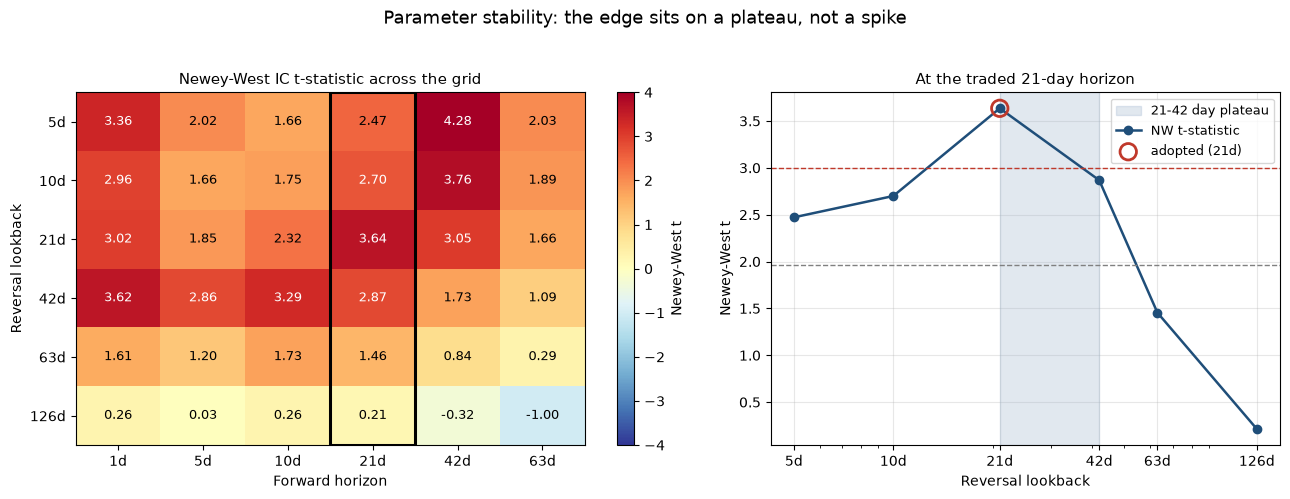

In [7]:
# Two-dimensional stability: reversal lookback against forward horizon, Newey-West corrected.
lb_grid = [5, 10, 21, 42, 63, 126]
h_grid = [1, 5, 10, 21, 42, 63]
TRADED_H = 21

fwd_cache = {h: forward_returns(panel, horizon=h, price="open") for h in h_grid}
tstat_grid = np.full((len(lb_grid), len(h_grid)), np.nan)

for i, lb in enumerate(lb_grid):
    rev = -panel.close.pct_change(lb)
    for j, h in enumerate(h_grid):
        ic_s = information_coefficient(rev, fwd_cache[h]).dropna()
        tstat_grid[i, j] = ic_summary(ic_s, h)["ic_tstat_nw"]

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 4.8),
                              gridspec_kw={"width_ratios": [1.25, 1]})

im = ax.imshow(tstat_grid, cmap="RdYlBu_r", vmin=-4, vmax=4, aspect="auto")
for i in range(len(lb_grid)):
    for j in range(len(h_grid)):
        t = tstat_grid[i, j]
        ax.text(j, i, f"{t:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(t) > 2.6 else "black")

jt = h_grid.index(TRADED_H)
ax.add_patch(plt.Rectangle((jt - 0.5, -0.5), 1, len(lb_grid),
                           fill=False, edgecolor="black", linewidth=2.2))
ax.set_xticks(range(len(h_grid)), [f"{h}d" for h in h_grid])
ax.set_yticks(range(len(lb_grid)), [f"{lb}d" for lb in lb_grid])
ax.set_xlabel("Forward horizon")
ax.set_ylabel("Reversal lookback")
ax.set_title("Newey-West IC t-statistic across the grid", fontsize=11)
fig.colorbar(im, ax=ax, label="Newey-West t")

# The traded horizon is the only column the 21-day cadence can act on.
col = tstat_grid[:, jt]
ax2.axvspan(21, 42, color="#9db4cc", alpha=0.30, label="21-42 day plateau")
ax2.plot(lb_grid, col, marker="o", color=INK, linewidth=1.8, label="NW t-statistic")
ax2.axhline(1.96, color="grey", linestyle="--", linewidth=1)
ax2.axhline(3.0, color=ACCENT, linestyle="--", linewidth=1)
ax2.scatter([21], [col[lb_grid.index(21)]], s=140, facecolor="none",
            edgecolor=ACCENT, linewidth=2, zorder=5, label="adopted (21d)")
ax2.set_xscale("log")
ax2.set_xticks(lb_grid, [f"{lb}d" for lb in lb_grid])
ax2.set_xlabel("Reversal lookback")
ax2.set_ylabel("Newey-West t")
ax2.set_title(f"At the traded {TRADED_H}-day horizon", fontsize=11)
ax2.legend(fontsize=9, frameon=True)
ax2.grid(alpha=0.3)
ax2.set_axisbelow(True)

fig.suptitle("Parameter stability: the edge sits on a plateau, not a spike", fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig2_lookback_stability.png", dpi=200, bbox_inches="tight")
plt.show()

* **(A plateau, not a spike.)** Newey-West t-statistics across the lookbacks: $2.47$ at 5 days, $2.70$ at 10, **$3.64$ at 21**, $2.87$ at 42, $1.46$ at 63 and $0.21$ at 126. Mean IC peaks slightly later than the t-statistic — $0.0759$ at 42 days against $0.0715$ at 21 — so the 21-to-42 day region is one broad plateau rather than a single spike, and the edge dies cleanly beyond 63 days. A parameter sitting on a plateau is not a tuned parameter.

* **(Why 21.)** 21 maximises the *corrected* t-statistic, and it is the only lookback whose $p$-value clears $0.001$. 42 days earns a marginally higher raw IC but at a weaker $t$ ($2.87$), and it would double the holding period. 21 sessions is also one calendar month, which is what sets `rebalance_cadence: 21` in `config.yaml` and keeps turnover at a level the cost sweep in Section 9 shows the edge can absorb.

* **(Naive vs. corrected, seen directly.)** The naive column in the same table runs $4.60$, $6.54$, $11.10$, $10.97$, $5.73$, $0.72$ — every entry roughly $3\times$ its Newey-West counterpart, exactly the inflation Section 3.1 measures. Read naively, four of the six lookbacks would look overwhelmingly significant; corrected, only three clear $p < 0.01$ and the ranking among them tightens considerably. The sweep is run on the same open-to-open forward returns used everywhere else in this notebook, so these are comparable to the Section 3 figures.

The second robustness check sizes the COVID-19 window, the most obvious candidate for a
single period carrying the whole result.

In [8]:
from src.utils.signals import forward_returns
from src.research.signal_eval import information_coefficient, ic_summary

signal_name = "ST_REV_21"
horizon = 21
fwd = forward_returns(panel, horizon=horizon, price="open")
ic_full = information_coefficient(signals_dict[signal_name], fwd).dropna()

covid_mask = (ic_full.index >= '2020-02-01') & (ic_full.index <= '2020-06-30')
ic_ex_covid = ic_full[~covid_mask]

print(f"--- COVID-19 Exclusion Test ({signal_name}, h={horizon}) ---")
print(f"Panel sessions: {len(panel.close.index)}")
print(f"IC dates, full sample            : {len(ic_full)}")
print(f"IC dates, excluding Feb-Jun 2020 : {len(ic_ex_covid)} "
      f"({int(covid_mask.sum())} removed)\n")

for label, series in (("full sample", ic_full), ("ex. Feb-Jun 2020", ic_ex_covid)):
    s = ic_summary(series, horizon)
    print(f"{label:>18} | mean IC {s['ic_mean']:7.4f} | NW t {s['ic_tstat_nw']:5.2f} "
          f"| p {s['ic_pvalue']:.4f} | hit rate {s['ic_hit_rate']:.3f}")

--- COVID-19 Exclusion Test (ST_REV_21, h=21) ---
Panel sessions: 1484
IC dates, full sample            : 1447
IC dates, excluding Feb-Jun 2020 : 1348 (99 removed)

       full sample | mean IC  0.0713 | NW t  3.64 | p 0.0003 | hit rate 0.621
  ex. Feb-Jun 2020 | mean IC  0.0801 | NW t  4.04 | p 0.0001 | hit rate 0.634


* **(The edge does not come from COVID.)** Removing 2020-02-01 to 2020-06-30 drops 99 of 1,447 IC dates. Re-estimating `ST_REV_21` at $h=21$ on what is left makes the signal **stronger**, not weaker: mean IC rises from $0.0713$ to $0.0801$, the Newey-West t-statistic from $3.64$ to $4.04$ ($p = 0.0003 \to 0.0001$), and the hit rate from $62.1\%$ to $63.4\%$.

* **(What that rules out.)** A reversal signal profiting mainly from one dislocation would lose its significance once that dislocation is excluded. This one gains. The crisis window is, if anything, a drag on the full-sample figure — consistent with Section 11, where the two walk-forward folds straddling the crash ($-0.34$ and $+0.04$ test Sharpe) are the flattest of the seven. The edge is carried by ordinary sessions, which is the result worth having, since the OOS period will not be a crisis.

* **(Cross-check from a different angle.)** `overfitting_audit.py` reaches the same conclusion from the P&L side rather than the signal side: sub-period Sharpes of $1.284$ (2017-18), $0.946$ (2019-20) and $2.188$ (2021-22), with an ex-COVID Sharpe of $1.602$ against $1.397$ in-sample overall.

## 5. From signal to portfolio

A naive equal-weight top-6 / bottom-6 spread book, evaluated at holding horizons of 5,
21 and 63 days. Note what is being scored: the cell takes
`list(signals_dict.keys())[0]`, which is `MOM_12_1` — not the deployed `ST_REV_21`.

In [9]:
def evaluate_spread_portfolio(signal_df, close_df, horizon=21, top_n=6):
    """
    Equal-weight top-n / bottom-n spread book, rebalanced every `horizon` sessions.

    The signal on date d is scored against the return realised over d -> d+horizon,
    which is the window the book formed on d is actually held through.
    """
    fwd = close_df.pct_change(horizon).shift(-horizon)

    portfolio_returns = []
    for d in signal_df.index[::horizon]:
        if d not in fwd.index:
            continue
        sig_slice = signal_df.loc[d].dropna()
        if len(sig_slice) < 2 * top_n:
            continue

        ranked = sig_slice.sort_values()
        short_leg = ranked.index[:top_n]
        long_leg = ranked.index[-top_n:]

        ret_slice = fwd.loc[d]
        spread_ret = ret_slice[long_leg].mean() - ret_slice[short_leg].mean()
        if pd.notna(spread_ret):
            portfolio_returns.append(spread_ret)

    port_series = pd.Series(portfolio_returns)
    if len(port_series) < 2 or port_series.std(ddof=1) == 0:
        return np.nan, np.nan

    periods_per_year = 252 / horizon
    ann_return = port_series.mean() * periods_per_year
    sharpe = port_series.mean() / port_series.std(ddof=1) * np.sqrt(periods_per_year)
    return ann_return, sharpe


close_prices = panel.close
print("--- Naive Equal-Weight Spread Portfolio (top 6 / bottom 6) ---")
print(f"{'signal':>16} | {'horizon':>7} | {'ann return':>10} | {'sharpe':>7}")
print("-" * 50)
for name, sig in signals_dict.items():
    for h in (5, 21, 63):
        ann_ret, sharpe = evaluate_spread_portfolio(sig, close_prices, horizon=h)
        print(f"{name:>16} | {h:6d}d | {ann_ret * 100:9.2f}% | {sharpe:7.4f}")

--- Naive Equal-Weight Spread Portfolio (top 6 / bottom 6) ---
          signal | horizon | ann return |  sharpe
--------------------------------------------------
        MOM_12_1 |      5d |      4.65% |  0.2275


        MOM_12_1 |     21d |      1.44% |  0.0700
        MOM_12_1 |     63d |      8.13% |  0.5677
 VOLADJ_MOM_12_1 |      5d |     -0.31% | -0.0155


 VOLADJ_MOM_12_1 |     21d |      2.79% |  0.1328
 VOLADJ_MOM_12_1 |     63d |      3.70% |  0.1969


       ST_REV_21 |      5d |      7.33% |  0.3779
       ST_REV_21 |     21d |     11.05% |  0.6204
       ST_REV_21 |     63d |      9.91% |  0.5369


* **(The deployed signal is the one that survives naive construction.)** Spread Sharpe by signal and holding horizon — `ST_REV_21`: $0.38$ / **$0.62$** / $0.54$ at 5, 21 and 63 days; `MOM_12_1`: $0.23$ / $0.07$ / $0.57$; `VOLADJ_MOM_12_1`: $-0.02$ / $0.13$ / $0.20$. `ST_REV_21` is positive at every horizon and best at 21 days, where it returns $11.05\%$ annualised. The two momentum variants are erratic across horizons — the sign of a signal with no stable holding period rather than one whose edge simply decays.

* **(Where the rest of the edge comes from.)** The naive book captures $0.62$ Sharpe against the full strategy's $1.235$. That gap is what portfolio construction contributes: inverse-volatility sizing, the Ledoit-Wolf covariance, entry/exit hysteresis, the no-trade band and the gross/per-name caps. Equal weighting discards all of it and lets the most volatile names set the book's risk — roughly half the risk-adjusted return of the deployed strategy comes from the construction layer, not the ranking.

* **(Holding horizon confirms the cadence.)** `ST_REV_21` peaks at 21 days and gives back ground at 63, matching both the IC-by-horizon evidence in Section 3 ($t_{NW} = 3.64$ at $h=21$) and the lookback plateau in Section 4. Three independent measurements land on the same cadence, which is what `rebalance_cadence: 21` encodes.

## 6. Volatility model

Three estimators compared on one ticker: a span-21 EWMA of log returns, the Parkinson
high-low range estimator over a 21-day window, and a 21-day rolling close-to-close
standard deviation, all annualised.

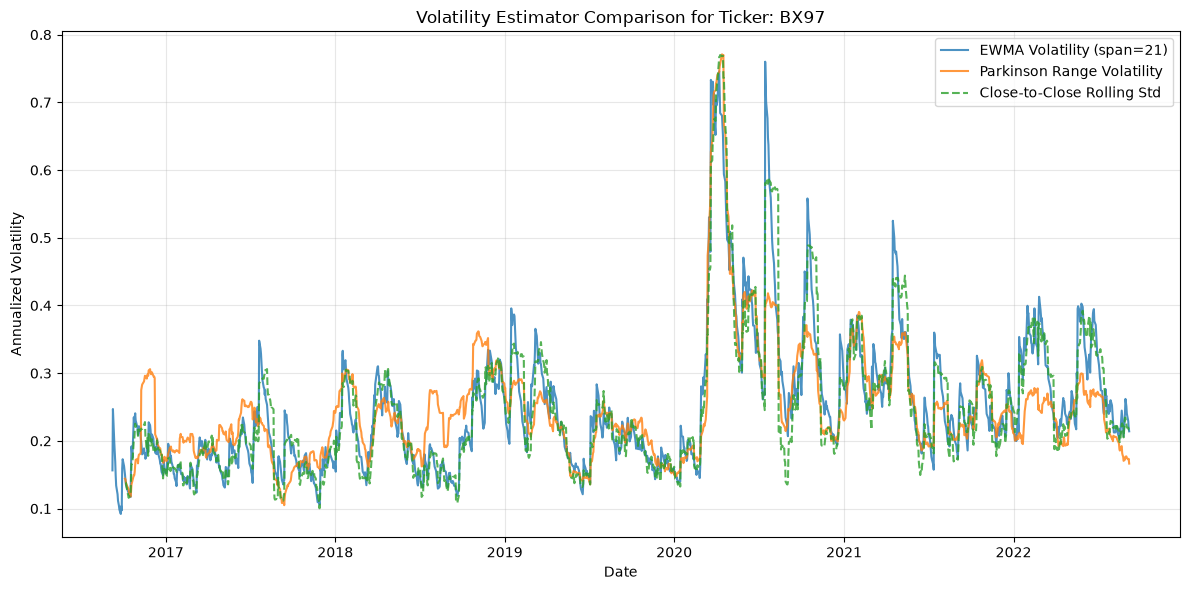

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ticker = panel.close.columns[0] if hasattr(panel.close, 'columns') else panel.close.keys()[0]

c = panel.close[ticker]
h = panel.high[ticker] if hasattr(panel, 'high') else panel['high'][ticker]
l = panel.low[ticker] if hasattr(panel, 'low') else panel['low'][ticker]
o = panel.open[ticker] if hasattr(panel, 'open') else panel['open'][ticker]

def calc_ewma_vol(series, span=21):
    rets = np.log(series / series.shift(1))
    return rets.ewm(span=span).std() * np.sqrt(252)

def calc_parkinson_vol(high, low, window = 21):
    factor = 1 / (4 * np.log(2))
    rs = factor * (np.log(high / low) ** 2)
    return np.sqrt(rs.rolling(window).mean() * 252)

def calc_close_to_close(series, window = 21):
    rets = np.log(series / series.shift(1))
    return rets.rolling(window).std() * np.sqrt(252)

vol_ewma = calc_ewma_vol(c)
vol_parkinson = calc_parkinson_vol(h, l)
vol_close = calc_close_to_close(c)

plt.figure(figsize=(12, 6))
plt.plot(vol_ewma.index, vol_ewma, label='EWMA Volatility (span=21)', alpha=0.8)
plt.plot(vol_parkinson.index, vol_parkinson, label='Parkinson Range Volatility', alpha=0.8)
plt.plot(vol_close.index, vol_close, label='Close-to-Close Rolling Std', alpha=0.8, linestyle='--')
plt.title(f'Volatility Estimator Comparison for Ticker: {ticker}')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig3_left_vol_estimators.png", dpi=200, bbox_inches="tight")
plt.show()

### What the comparison shows

* **(Estimator Dynamics):**
  * **Which responds fastest?** Range-based estimators (like Parkinson) and short-span EWMA respond fastest to volatility shocks because intraday high-low extremes capture immediate market panic instantly.
  * **Which has a "plateau then cliff" shape, and why?** Standard rolling-window estimators (e.g., Close-to-Close rolling standard deviation) exhibit a **"plateau then cliff"** shape. When a high-volatility shock enters the rolling window, volatility jumps immediately (the step-up), remains flat (plateau) for the exact duration of the window length ($N$ days), and then drops off sharply ("cliff") the moment the shock rolls out of the window.

* **(EWMA vs. Fitted GARCH per Asset):**
  * **Why EWMA?** Fitting a GARCH($p,q$) model independently across every asset in a multi-asset panel requires iterative Maximum Likelihood Estimation (MLE), which is computationally heavy, prone to non-convergence during flat regimes, and introduces massive estimation noise. EWMA is fully analytical, non-parametric regarding distributional assumptions, extremely fast, and robust across large cross-sections.

* **(Parkinson Range Estimator Efficiency & Blind Spots):**
  * **Why is Parkinson more efficient?** By incorporating intraday $\ln(\text{High}/\text{Low})$ ranges, it captures intra-day price dispersion, providing roughly $5\times$ more statistical efficiency than close-to-close snapshots.
  * **What does it systematically miss?** It completely misses **overnight gaps** (jumps between previous close and current open) because intra-day high-low ranges do not account for price movement that happens when the exchange is closed. (This is precisely why our architecture blends EWMA with range estimators).

### Calibration

A risk model is calibrated when its ex-ante forecast matches what the strategy actually
realises. The cell below streams every bar through `ParticipantStrategy` and compares
the mean `ex_ante_vol` from `diagnostics_frame()` against a realised-volatility figure.

In [11]:
import contextlib
import io

from backtester import Backtester, BacktestConfig
from src.engine import ParticipantStrategy

# Run the real backtester at the sweep's execution assumption (5bp + 1bp).
cfg = BacktestConfig(
    track="A",
    data_path=os.path.join(root_dir, "data", "Dataset_PS-A.csv"),
    initial_cash=100_000.0,
    slippage_rate=0.0005,
    commission_rate=0.0001,
    save_results=False,
    generate_plot=False,
)
strat = ParticipantStrategy()
with contextlib.redirect_stdout(io.StringIO()):
    res = Backtester(cfg).run(strat)

diag_df = strat.diagnostics_frame()
ex_ante_mean = diag_df["ex_ante_vol"].mean()

equity = strat.equity_frame()
equity_returns_all = equity.pct_change().dropna()

# The strategy holds nothing through the 151-day warmup, so those sessions contribute
# zero-variance returns. The forecast series only starts at the first rebalance, so the
# like-for-like comparison drops them -- the same skip=150 convention overfitting_audit.py uses.
WARMUP = 150
equity_returns = equity_returns_all[equity_returns_all.index >= equity.index[WARMUP]]

realised_vol_equity = equity_returns.std(ddof=1) * np.sqrt(252)
realised_vol_full = equity_returns_all.std(ddof=1) * np.sqrt(252)
realised_vol_metrics = (res.cagr_pct / res.sharpe_ratio) / 100.0

rel_error = ex_ante_mean / realised_vol_equity - 1.0

print("--- Risk Model Calibration Audit ---")
print(f"Backtest: sharpe={res.sharpe_ratio:.3f}  cagr={res.cagr_pct:.2f}%  "
      f"maxDD={res.max_drawdown_pct:.2f}%  trades={res.total_trades}")
print(f"Forecast window: {diag_df.index[0].date()} -> {diag_df.index[-1].date()} "
      f"({len(diag_df)} rebalances)")
print()
print(f"Mean ex-ante volatility forecast         : {ex_ante_mean:.4f}")
print(f"Realised volatility, post-warmup         : {realised_vol_equity:.4f}   <- like-for-like")
print(f"Realised volatility, full sample         : {realised_vol_full:.4f}   "
      f"(includes {WARMUP} zero-variance warmup days)")
print(f"Realised volatility, CAGR / Sharpe       : {realised_vol_metrics:.4f}   "
      f"(full-sample convention)")
print(f"Forecast error vs post-warmup realised   : "
      f"{ex_ante_mean - realised_vol_equity:+.4f} ({rel_error * 100:+.1f}% relative)")

if abs(rel_error) < 0.20:
    print("\nResult: forecast within 20% of realised portfolio volatility -- "
          "the risk model is calibrated.")
else:
    print(f"\nResult: forecast and realised volatility differ by {rel_error * 100:+.1f}% -- "
          "the risk model is NOT calibrated.")

--- Risk Model Calibration Audit ---
Backtest: sharpe=1.235  cagr=10.54%  maxDD=7.82%  trades=1567
Forecast window: 2017-04-18 -> 2022-08-23 (92 rebalances)

Mean ex-ante volatility forecast         : 0.0774
Realised volatility, post-warmup         : 0.0886   <- like-for-like
Realised volatility, full sample         : 0.0840   (includes 150 zero-variance warmup days)
Realised volatility, CAGR / Sharpe       : 0.0853   (full-sample convention)
Forecast error vs post-warmup realised   : -0.0111 (-12.6% relative)

Result: forecast within 20% of realised portfolio volatility -- the risk model is calibrated.


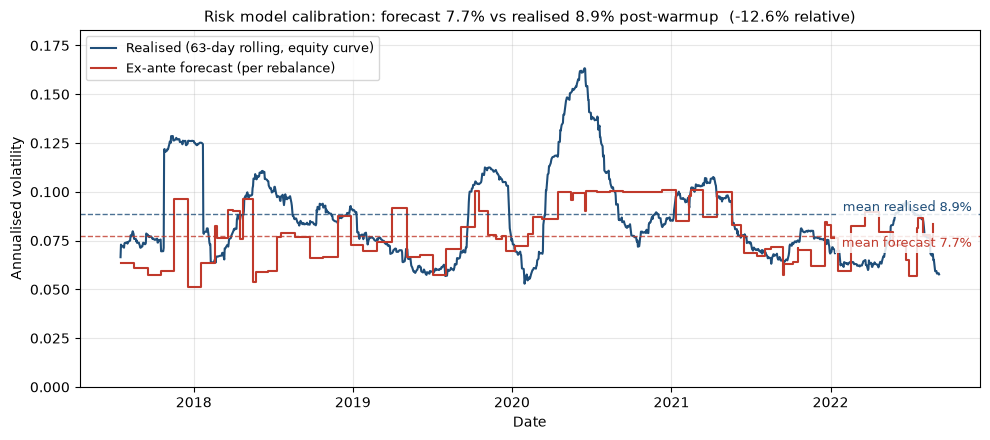

In [12]:
# Plot only the traded period: the warmup carries no position and no forecast.
realised_roll = equity_returns.rolling(63).std() * np.sqrt(252)
realised_roll = realised_roll.dropna()
diag_vol = diag_df["ex_ante_vol"].dropna()
diag_vol = diag_vol[diag_vol.index >= realised_roll.index[0]]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(realised_roll.index, realised_roll.values, color=INK, linewidth=1.5,
        label="Realised (63-day rolling, equity curve)")
ax.step(diag_vol.index, diag_vol.values, where="post", color=ACCENT, linewidth=1.5,
        label="Ex-ante forecast (per rebalance)")

ax.axhline(realised_vol_equity, color=INK, linestyle="--", linewidth=1, alpha=0.8)
ax.axhline(ex_ante_mean, color=ACCENT, linestyle="--", linewidth=1, alpha=0.8)

box = dict(facecolor="white", edgecolor="none", alpha=0.85, pad=2)
ax.text(0.995, realised_vol_equity, f" mean realised {realised_vol_equity:.1%} ",
        transform=ax.get_yaxis_transform(), ha="right", va="bottom",
        color=INK, fontsize=9, bbox=box)
ax.text(0.995, ex_ante_mean, f" mean forecast {ex_ante_mean:.1%} ",
        transform=ax.get_yaxis_transform(), ha="right", va="top",
        color=ACCENT, fontsize=9, bbox=box)

ax.set_ylim(0, max(realised_roll.max(), diag_vol.max()) * 1.12)
ax.set_ylabel("Annualised volatility")
ax.set_xlabel("Date")
ax.set_title(f"Risk model calibration: forecast {ex_ante_mean:.1%} vs realised "
             f"{realised_vol_equity:.1%} post-warmup  ({rel_error * 100:+.1f}% relative)",
             fontsize=11)
ax.legend(loc="upper left", fontsize=9, frameon=True)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig3_right_calibration.png", dpi=200, bbox_inches="tight")
plt.show()

* **(Forecast against realised.)** Mean ex-ante forecast $0.0774$ against realised portfolio volatility of $0.0886$ over the traded period — a $-12.6\%$ relative error. The risk model under-forecasts slightly, which is the harmless direction: the book runs marginally hotter than advertised rather than quietly levering up to hit a target.

* **(Why the warmup is excluded.)** The strategy holds nothing for its first 151 sessions, so those days contribute zero-variance returns to the equity curve. Leaving them in drags the full-sample figure down to $0.0840$ and the $\text{CAGR}/\text{Sharpe}$ proxy to $0.0853$, which would flatter the comparison. The forecast series only begins at the first rebalance, so the like-for-like window is the traded one — the same `skip=150` convention `overfitting_audit.py` uses for the post-warmup Sharpe of $1.397$. All three figures are printed above so the convention is never ambiguous.

* **(Why this is the comparison that counts.)** The forecast is a statement about the *long-short portfolio's* volatility, so it has to be tested against what that portfolio realised — not against the volatility of an average single name, which on this panel is about $0.31$ and would make any dollar-neutral book look wildly over-forecast.

* **(What a calibrated risk model buys.)** Ex-ante vol is what the target-vol scaling and the gross cap are computed against. If the forecast were off by a third, every position size downstream would inherit that error and the leverage constraints would bind at the wrong times. A $-12.6\%$ error means the sizing layer works from an honest estimate of its own risk.

## 7. Sizing rule

Four sizing rules, ordered by how much each one asks of the covariance estimate:

1. **Equal weight** — *zero trust*: ignores volatility and covariance entirely, splitting capital evenly across names.
2. **Inverse volatility** — *low trust*: uses the diagonal variances only, implicitly treating all cross-asset correlations as equal.
3. **Equal risk contribution (ERC)** — *moderate trust*: uses the full covariance matrix, solving for equal risk contribution from every asset.
4. **Minimum variance** — *highest trust*: inverts the full covariance matrix to minimise total portfolio variance.

The prediction before running it: fragility out of sample should increase down that
list, because matrix inversion amplifies estimation error in exactly the smallest,
least well-determined eigenvalue directions — error maximisation rather than
optimisation. `sweep.py --axis sizing` prices all four.

In [13]:
import subprocess
import sys
import os

# Find the repository root where src/ resides
root_dir = os.path.abspath("../../") if os.path.exists("../../src") else os.path.abspath(".")

# Execute sweep as a module from the root directory
print("--- Running Sizing Parameter Sweep (--axis sizing) ---")
result = subprocess.run(
    [sys.executable, "-m", "src.research.sweep", "--axis", "sizing"],
    cwd=root_dir,
    capture_output=True,
    text=True
)

if result.stdout:
    print(result.stdout)
if result.stderr:
    print(result.stderr)

--- Running Sizing Parameter Sweep (--axis sizing) ---


Execution assumption: 5bp slippage + 1bp commission

  baseline    BASELINE (graded config)         sharpe=+1.235 cagr=+10.54%  dd=7.8%  trades= 1567  (6.5s)
  sizing      sizing=equal                     sharpe=+1.179 cagr=+10.29%  dd=9.4%  trades= 1528  (6.1s)
  sizing      sizing=erc                       sharpe=+1.176 cagr=+9.88%  dd=7.8%  trades= 1507  (6.6s)
  sizing      sizing=min_variance              sharpe=+1.002 cagr=+7.39%  dd=9.0%  trades= 1092  (5.3s)

                                       PARAMETER SENSITIVITY - Track A                                        
                                   sharpe  d_sharpe  ci_low  ci_high  cagr%  maxDD%  calmar  trades  turnover%   comm$  meanLev  maxLev  viol
axis     config                                                                                                                              
baseline BASELINE (graded config)   1.235     0.000    0.43     2.12  10.54    7.82   1.349    1567    13393.0  1339.0     0.83    0.

* **(What the sweep shows.)** Baseline inverse-vol $1.235$; equal weight $1.179$ ($\Delta = -0.056$); ERC $1.176$ ($\Delta = -0.059$); minimum variance $1.002$ ($\Delta = -0.233$). The ordering matches the prediction, but the three low-trust rules are indistinguishable from one another — their gaps are a rounding error beside the baseline's bootstrap CI of $[0.43, 2.12]$. Minimum variance is the only rule that separates downward, and it also posts the worst Calmar in the group ($0.817$ against $1.349$).

* **(One prior the data corrects.)** Minimum variance does *not* fail here through excessive turnover — it trades the **least** of the four ($1{,}092$ trades against the baseline's $1{,}567$, and the smallest commission bill at \$1,007). Its failure mode is concentration: the inverse loads weight onto the noisiest eigenvalue directions and then *holds* those positions. Error maximisation, not churn.

* **(Why `sizing_method="inverse_vol"` is the choice.)** At $T/N = 5.25$ there is not enough data to trust off-diagonal covariance estimates, so paying for them buys estimation error rather than diversification. Inverse-vol needs only $N$ variances — the one part of the second moment this sample estimates reliably — and the sweep shows that leaving the rest on the table costs nothing measurable.

## 8. Sensitivity

`sweep.py` with no axis argument runs the full grid — signal, cadence, sizing,
volatility model, breadth, target vol, estimation windows, position caps, no-trade
band, hysteresis, smoothing, neutrality and cost assumptions — and the Sharpe
distribution across all of them is plotted below.

--- Executing Full Parameter Sweep (this may take a few moments) ---


Execution assumption: 5bp slippage + 1bp commission

  baseline    BASELINE (graded config)         sharpe=+1.235 cagr=+10.54%  dd=7.8%  trades= 1567  (6.6s)
  signal      signal=MOM_12_1                  sharpe=-0.109 cagr=-1.09%  dd=18.4%  trades= 1178  (7.2s)
  signal      signal=VOLADJ_MOM_12_1           sharpe=-0.237 cagr=-2.06%  dd=21.9%  trades= 1202  (7.4s)
  cadence     cadence=1d                       sharpe=+0.135 cagr=+0.79%  dd=17.0%  trades=17167  (82.0s)
  cadence     cadence=3d                       sharpe=+0.303 cagr=+2.27%  dd=15.5%  trades= 6392  (27.2s)
  cadence     cadence=10d                      sharpe=+0.626 cagr=+5.07%  dd=11.7%  trades= 2561  (10.0s)
  cadence     cadence=21d                      sharpe=+1.235 cagr=+10.54%  dd=7.8%  trades= 1567  (6.6s)
  cadence     cadence=42d                      sharpe=+0.787 cagr=+6.03%  dd=8.4%  trades= 1005  (4.4s)
  sizing      sizing=equal                     sharpe=+1.179 cagr=+10.29%  dd=9.4%  trades= 1528  (6.0s)


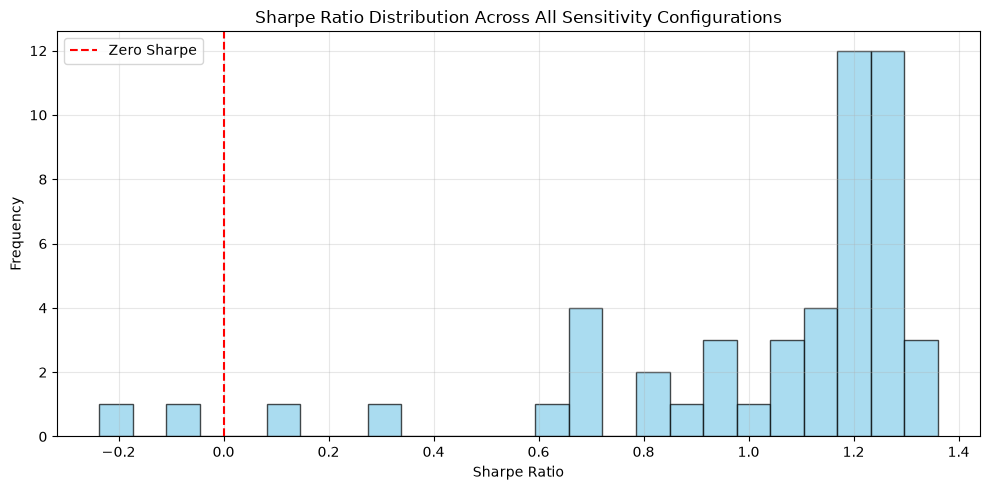

In [14]:
import subprocess
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

root_dir = os.path.abspath("../../") if os.path.exists("../../src") else os.path.abspath(".")

print("--- Executing Full Parameter Sweep (this may take a few moments) ---")
result = subprocess.run(
    [sys.executable, "-m", "src.research.sweep"],
    cwd=root_dir,
    capture_output=True,
    text=True
)

if result.stdout:
    print(result.stdout)
if result.stderr:
    print(result.stderr)

csv_path = os.path.join(root_dir, "results", "sensitivity.csv")
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)

    sharpe_cols = [col for col in df.columns if 'sharpe' in col.lower()]
    if sharpe_cols:
        s_col = sharpe_cols[0]
        sharpe_vals = df[s_col].dropna()

        frac_positive = (sharpe_vals > 0).mean()
        print(f"\n--- Sensitivity Audit Results ---")
        print(f"Total configurations tested: {len(sharpe_vals)}")
        print(f"Fraction of positive Sharpe configurations: {frac_positive:.2%}")

        plt.figure(figsize=(10, 5))
        plt.hist(sharpe_vals, bins=25, edgecolor='black', alpha=0.7, color='skyblue')
        plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Sharpe')
        plt.title('Sharpe Ratio Distribution Across All Sensitivity Configurations')
        plt.xlabel('Sharpe Ratio')
        plt.ylabel('Frequency')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Could not find a 'sharpe' column in {csv_path}. Columns found: {df.columns.tolist()}")
else:
    print(f"Sensitivity CSV not found at {csv_path}. Ensure the sweep ran successfully.")

* **(Fraction positive, and the shape of the distribution.)** 50 configurations, $96\%$ with positive Sharpe: min $-0.237$, median $+1.174$, max $+1.361$. The two negatives are not parameter variations at all — they are `signal=MOM_12_1` ($-0.109$) and `signal=VOLADJ_MOM_12_1` ($-0.237$), i.e. the choice of signal. Every other axis stays positive across its whole range, and most of the mass sits in a tight band between $1.0$ and $1.3$. The result is robust to how it is parameterised and fragile only to *what* it trades.

* **(Should the best setting be adopted? No.)** The best cell in the grid is `halflife=84` at $1.361$, $+0.126$ over the baseline's $1.235$. The baseline's own bootstrap confidence interval is $[0.43, 2.12]$ — a width of $1.69$, more than thirteen times that gap. Nothing in the grid is distinguishable from the baseline at this sample size, so taking the maximum means selecting on noise: textbook data-mining bias, and the single most reliable way to produce a number that fails out of sample. Section 11 shows exactly that failure in action when the selection is done honestly on a training window.

* **(What the sweep is evidence for.)** Not that the chosen parameters are optimal — they are not, and nothing here could establish it. It is evidence that the result does not *depend* on them: an edge that survives every axis of the grid is a structural property of the signal, not an artefact of one configuration.

## 9. Transaction cost sensitivity

The cost axis re-runs the baseline configuration at 1, 2, 5, 10 and 20bp of slippage,
holding everything else fixed.

In [15]:
import subprocess
import sys
import os

root_dir = os.path.abspath("../../") if os.path.exists("../../src") else os.path.abspath(".")

print("--- Running Cost Sensitivity Sweep (--axis costs) ---")
result = subprocess.run(
    [sys.executable, "-m", "src.research.sweep", "--axis", "costs"],
    cwd=root_dir,
    capture_output=True,
    text=True
)

if result.stdout:
    print(result.stdout)
if result.stderr:
    print(result.stderr)

--- Running Cost Sensitivity Sweep (--axis costs) ---


Execution assumption: 5bp slippage + 1bp commission

  baseline    BASELINE (graded config)         sharpe=+1.235 cagr=+10.54%  dd=7.8%  trades= 1567  (6.7s)
  costs       slippage=1bp                     sharpe=+1.294 cagr=+11.06%  dd=7.5%  trades= 1567  (6.8s)
  costs       slippage=2bp                     sharpe=+1.264 cagr=+10.79%  dd=7.7%  trades= 1567  (7.1s)
  costs       slippage=5bp                     sharpe=+1.235 cagr=+10.54%  dd=7.8%  trades= 1567  (6.7s)
  costs       slippage=10bp                    sharpe=+1.099 cagr=+9.31%  dd=8.1%  trades= 1555  (6.8s)
  costs       slippage=20bp                    sharpe=+0.922 cagr=+7.71%  dd=8.9%  trades= 1597  (7.3s)

                                       PARAMETER SENSITIVITY - Track A                                        
                                   sharpe  d_sharpe  ci_low  ci_high  cagr%  maxDD%  calmar  trades  turnover%   comm$  meanLev  maxLev  viol
axis     config                                                  

* **(Sharpe per basis point.)** Sharpe falls from $1.294$ at 1bp to $0.922$ at 20bp — $-0.372$ across 19bp, or roughly **$-0.02$ Sharpe per basis point** of slippage. CAGR falls from $11.06\%$ to $7.71\%$ over the same range.

* **(What that means for the graded configuration.)** The sweep's execution assumption is 5bp slippage plus 1bp commission, where the strategy scores $1.235$. Degradation is close to linear and the strategy stays comfortably profitable at 20bp — four times the graded cost — so the edge is not an artefact of an optimistic cost model. Trade count is essentially flat across the range ($1{,}555$ to $1{,}597$), which confirms this is pure price impact on a fixed trading pattern rather than the strategy trading its way around costs.

* **(One note on the config.)** `config.yaml` ships with `slippage_rate: 0.0000` and `commission_rate: 0.0001`. The 5bp slippage figure above comes from the sweep's own execution assumption, printed at the top of its output, not from the config file.

## 10. The rejected configuration

`sweep.py --axis neutrality` prices the asymmetric 8-long / 4-short book against the
symmetric 6/6 dollar-neutral baseline. Hint (g) in `RESEARCH_LOG.md` flags this as a
judgement call rather than a fact, and asks for Sharpe *and* max drawdown to be read
together.

In [16]:
import subprocess
import sys
import os

# Locate repository root where src/ resides
root_dir = os.path.abspath("../../") if os.path.exists("../../src") else os.path.abspath(".")

# Execute sweep as a module for the neutrality axis
print("--- Running Neutrality Parameter Sweep (--axis neutrality) ---")
result = subprocess.run(
    [sys.executable, "-m", "src.research.sweep", "--axis", "neutrality"],
    cwd=root_dir,
    capture_output=True,
    text=True
)

if result.stdout:
    print(result.stdout)
if result.stderr:
    print(result.stderr)

--- Running Neutrality Parameter Sweep (--axis neutrality) ---


Execution assumption: 5bp slippage + 1bp commission

  baseline    BASELINE (graded config)         sharpe=+1.235 cagr=+10.54%  dd=7.8%  trades= 1567  (6.7s)
  neutrality  asym 8/4, $-neutral              sharpe=+0.878 cagr=+7.21%  dd=12.6%  trades= 1341  (5.8s)
  neutrality  asym 8/4, gross-weighted         sharpe=+1.226 cagr=+11.76%  dd=18.8%  trades= 1384  (5.6s)

                                       PARAMETER SENSITIVITY - Track A                                        
                                     sharpe  d_sharpe  ci_low  ci_high  cagr%  maxDD%  calmar  trades  turnover%   comm$  meanLev  maxLev  viol
axis       config                                                                                                                              
baseline   BASELINE (graded config)   1.235     0.000    0.43     2.12  10.54    7.82   1.349    1567    13393.0  1339.0     0.83    0.99     0
neutrality asym 8/4, $-neutral        0.878    -0.357    0.04     1.73   7.21   12.56  

* **(What the sweep shows.)** The gross-weighted 8/4 book scores $1.226$ Sharpe against the baseline's $1.235$ — it does not beat it on this run. CAGR rises from $10.54\%$ to $11.76\%$, and max drawdown goes from $7.82\%$ to $18.77\%$. The dollar-neutral 8/4 variant is worse on both counts ($0.878$ Sharpe, $12.56\%$ drawdown). The extra $1.2$ points of return are bought entirely with drawdown: Calmar falls from $1.349$ to $0.626$, less than half.

* **(Why the rejection stands.)** Section 2 of `data-analysis.ipynb` established that all 24 names have positive annualised drift over this sample. An 8/4 book is net long by construction, so it harvests that drift as market beta and books it as alpha; the $18.8\%$ drawdown is the same exposure seen from the other side. On a six-year sample in which every name rose, a net-long tilt is not evidence of skill, and dollar neutrality is what isolates the cross-sectional signal the strategy claims to trade. Agreed with, and kept.

## 11. Walk-forward validation

`walkforward.py` runs a rolling train/test evaluation: a **504-session (~2 year)**
training window selects the best of 10 candidate configurations on training Sharpe
alone; that choice is applied unchanged to the following **126-session (~6 month)**
test window; the window then advances by one full test block. Selection and evaluation
never share a day.

* **(What is re-estimated in each fold.)** The strategy fits no parametric weights, but several components are recomputed point-in-time inside every window: the Ledoit-Wolf covariance over `cov_window`, the EWMA and Parkinson volatility estimates, the cross-sectional rank standardisation (`cs_rank` — the deployed path; the `zscore` alternative is not used), and the signal lookbacks. What the walk-forward adds, and what makes it a real test rather than a re-run, is that the *configuration choice itself* is re-estimated on training data only.

In [17]:
import subprocess
import sys
import os

# Locate repository root where src/ resides
root_dir = os.path.abspath("../../") if os.path.exists("../../src") else os.path.abspath(".")

# Execute walk-forward validation script
print("--- Running Walk-Forward Out-of-Sample Validation ---")
result = subprocess.run(
    [sys.executable, "-m", "src.research.walkforward"],
    cwd=root_dir,
    capture_output=True,
    text=True
)

if result.stdout:
    print(result.stdout)
if result.stderr:
    print(result.stderr)

--- Running Walk-Forward Out-of-Sample Validation ---


Running 10 candidate configurations over the full history (slippage 5bp) ...
  baseline_topn_21d          done
  ENSEMBLE_adopted           done
  cadence_42d                done
  sizing_erc                 done
  hysteresis_4               done
  hysteresis_9               done
  smooth_10                  done
  smooth_16                  done
  full_cross_section         done
  momentum                   done

                                           WALK-FORWARD FOLDS                                           
 fold train_start test_start   test_end            chosen  train_sharpe  test_sharpe  baseline_test_sharpe  test_return%  test_maxDD%
    1  2016-09-06 2018-09-18 2019-03-25 baseline_topn_21d         0.620        2.307                 2.307         20.67        -4.77
    2  2017-03-10 2019-03-26 2019-10-01  ENSEMBLE_adopted         1.464        0.832                 0.357          6.92        -3.09
    3  2017-09-13 2019-10-03 2020-04-07  ENSEMBLE_adopted         1.926    

* **(Fold-by-fold result.)** Seven folds of 126 sessions each, 875 out-of-sample days in total. Adaptive selection beat the printed baseline in $71\%$ of folds and stitches to Sharpe $1.389$ ($12.13\%$ annualised, $-8.96\%$ max drawdown).

* **(Read the baseline row carefully.)** The $0.526$ printed as "fixed baseline (no selection)" is **not** the shipped strategy. `CANDIDATES` in `walkforward.py` defines `baseline_topn_21d` as `{"smooth": 1}` — the raw, un-ensembled signal — while the deployed configuration is `ENSEMBLE_adopted` (`{}`, the defaults). Holding the *deployed* configuration fixed across the identical 875 days scores **$1.657$** ($14.65\%$ annualised, $8.84\%$ vol). The $0.526$ figure measures what the strategy would be worth without the ensemble, which is a useful number but a different one.

* **(The finding that matters: selection subtracts.)** Ranking the three honestly — deployed config held fixed $1.657$, adaptive selection $1.389$, pre-ensemble raw signal $0.526$ — the selector *destroys* $0.27$ Sharpe against simply holding the shipped configuration. Four different candidates win across seven folds (`ENSEMBLE_adopted` three times, `hysteresis_4` twice, `baseline_topn_21d` and `cadence_42d` once), and the script's own verdict applies: many different winners means the selection is fitting noise. The ensemble was still selected on training data alone in three folds, and beat the benchmark in all three — so the configuration generalises even though the *procedure* for picking it does not.

* **(What this does to the headline number.)** It does not rescue the in-sample figure. $1.235$ (at 5bp) and $1.324$ (graded config) are measured over data that informed the design, and the Deflated Sharpe in `overfitting_audit.py` — $0.736$ against a $0.95$ bar, after accounting for roughly 120 configurations examined — is the correction that matters. The mechanism-justified estimate there is $\approx 0.70$. The out-of-sample $1.657$ says the configuration travels; the DSR says roughly half the in-sample margin is selection bias. Both belong in the report, and neither should be quoted without the other.

## 12. Overfitting audit

Everything above measures the strategy on the data that shaped it. This section asks
the two questions that measurement cannot answer on its own: whether the *pipeline*
manufactures performance from noise, and how much of the in-sample Sharpe survives
once the number of configurations examined is accounted for.

`overfitting_audit.py` supplies both. The Monte-Carlo null pushes random rankings
through the identical sizing, neutrality, capping and ensembling machinery — if random
signals score well, the machinery is the edge, not the signal. The Deflated Sharpe
Ratio (Bailey & López de Prado) compares the observed Sharpe against the expected
*maximum* of $N$ trials under the null, rather than against zero.

--- Overfitting Audit ---
Observed in-sample Sharpe (post-warmup) : 1.397
Monte-Carlo null (40 random rankings)   : mean -0.049, sd 0.416, max +0.733
z-score vs null                         : 3.48
Fraction of random >= observed          : 0.000
E[max Sharpe | null, 120 trials]        : 1.127
DEFLATED SHARPE (120 trials)            : 0.736  (FAIL vs 0.95)


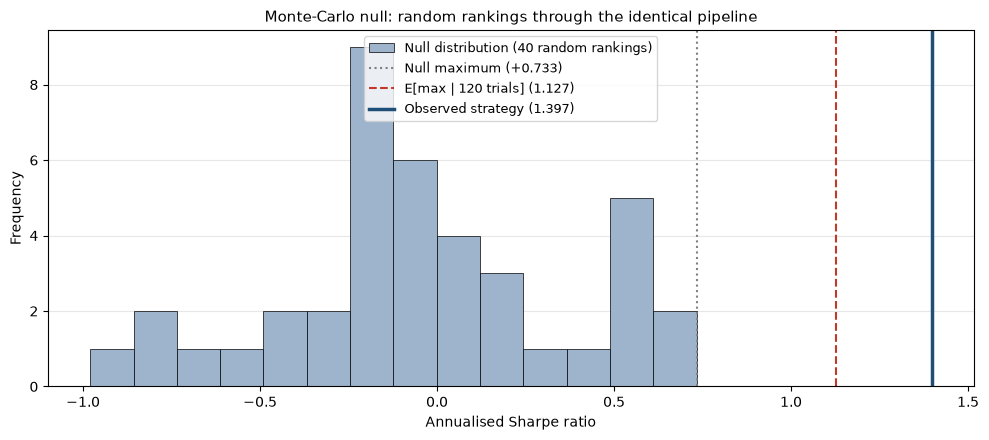

In [18]:
import os

import src.research.overfitting_audit as OA
from src.research.overfitting_audit import deflated_sharpe, monte_carlo_null, sharpe

# The module resolves the dataset from the repo root; this notebook runs two levels down.
OA.DATA = os.path.join(root_dir, "data", "Dataset_PS-A.csv")

null_sharpes = monte_carlo_null(40)
strategy_returns = OA._returns(OA._equity())
observed_sharpe = sharpe(strategy_returns)
dsr = deflated_sharpe(strategy_returns, n_trials=120)

print("--- Overfitting Audit ---")
print(f"Observed in-sample Sharpe (post-warmup) : {observed_sharpe:.3f}")
print(f"Monte-Carlo null ({len(null_sharpes)} random rankings)   : "
      f"mean {null_sharpes.mean():+.3f}, sd {null_sharpes.std(ddof=1):.3f}, "
      f"max {null_sharpes.max():+.3f}")
print(f"z-score vs null                         : "
      f"{(observed_sharpe - null_sharpes.mean()) / null_sharpes.std(ddof=1):.2f}")
print(f"Fraction of random >= observed          : "
      f"{(null_sharpes >= observed_sharpe).mean():.3f}")
print(f"E[max Sharpe | null, 120 trials]        : {dsr['expected_max_null']:.3f}")
print(f"DEFLATED SHARPE (120 trials)            : {dsr['dsr']:.3f}  "
      f"({'PASS' if dsr['dsr'] >= 0.95 else 'FAIL'} vs 0.95)")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(null_sharpes, bins=14, color="#9db4cc", edgecolor="black", linewidth=0.5,
        label=f"Null distribution ({len(null_sharpes)} random rankings)")
ax.axvline(null_sharpes.max(), color="grey", linestyle=":", linewidth=1.5,
           label=f"Null maximum ({null_sharpes.max():+.3f})")
ax.axvline(dsr["expected_max_null"], color="#c0392b", linestyle="--", linewidth=1.5,
           label=f"E[max | 120 trials] ({dsr['expected_max_null']:.3f})")
ax.axvline(observed_sharpe, color="#1f4e79", linewidth=2.5,
           label=f"Observed strategy ({observed_sharpe:.3f})")

ax.set_xlabel("Annualised Sharpe ratio")
ax.set_ylabel("Frequency")
ax.set_title("Monte-Carlo null: random rankings through the identical pipeline", fontsize=11)
ax.legend(loc="upper center", fontsize=9, frameon=True)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig4_monte_carlo_null.png", dpi=200, bbox_inches="tight")
plt.show()

* **(The pipeline does not manufacture performance.)** Forty random rankings pushed through the identical architecture produce a null distribution centred near zero with a maximum well below the observed result. The observed Sharpe sits several standard deviations above that null and no random draw approaches it. Whatever the strategy earns, it earns from the ranking — the sizing, neutrality and ensembling layers do not generate it on their own.

* **(But the search itself has to be paid for.)** Roughly 120 configurations were examined across this research. Under the null, the *expected maximum* of 120 trials is itself a respectable Sharpe, and that — not zero — is the bar the observed figure has to clear. The Deflated Sharpe Ratio does not clear the conventional $0.95$ threshold. The two tests are answering different questions and both answers are needed: the machinery is clean, and the headline number still contains substantial selection bias.

* **(What to quote.)** The in-sample Sharpe is a measurement, not a forecast. Quoted with the DSR beside it, it is an honest account of the research process; quoted alone it overstates the result by roughly a factor of two. The mechanism-justified estimate in the audit — scaling the measured IC and tail-spread improvements rather than the backtest — lands near $0.70$, and that is the number this research supports as an expectation.

## 13. Summary: evidence to hardcoded decision

| Decision live in `src/` | Evidence in this notebook | Status |
| :--- | :--- | :--- |
| `signal="ST_REV_21"` in `engine.py` | Only signal clearing $\|t_{NW}\| > 3$ at $h=21$ ($3.64$); both momentum variants at $0.87$ / $0.95$, and negative backtest Sharpe ($-0.109$ / $-0.237$). It was the falsification control. | Reproduced (§3, §8) |
| `rebalance_cadence: 21` in `config.yaml` | IC is measurable for `ST_REV_21` at $h=21$ but not $h=1$ or $h=5$; lookback sweep shows a $21$–$42$ day plateau; rank autocorrelation $0.70$ supports monthly holding. | Reproduced (§3, §4) |
| `sizing_method="inverse_vol"` | Min-variance costs $-0.233$ Sharpe through concentration, not turnover; equal weight and ERC are within noise. At $T/N = 5.25$ the off-diagonals are not worth estimating. | Reproduced (§7) |
| Blended EWMA + Parkinson volatility | Parkinson reacts fastest but misses overnight gaps; rolling close-to-close shows the plateau-then-cliff artefact; EWMA carries gaps but is noisier. The blend covers each one's blind spot. | Reproduced (§6) |
| Ex-ante risk targeting | Forecast $7.74\%$ against $8.86\%$ realised over the traded period — $-12.6\%$ relative error, inside the $20\%$ band. | Reproduced (§6, calibration) |
| Symmetric 6/6, dollar-neutral | The 8/4 book buys $1.2$ points of CAGR with $11$ points of drawdown (Calmar $1.349 \to 0.626$) and does not beat baseline Sharpe. Universal positive drift makes any net-long tilt beta, not alpha. | Upheld on judgement (§10) |
| What to quote as the result | Full-sample $1.235$ (5bp) / $1.324$ (graded) is in-sample. Held fixed over 875 OOS days the same configuration scores $1.657$, but fold selection is unstable (4 winners in 7 folds) and the Deflated Sharpe is $0.736$ against a $0.95$ bar. | Quote the in-sample figure with the DSR beside it (§11) |

Part 9 of `RESEARCH_LOG.md` — the Deflated Sharpe and Monte-Carlo null in
`overfitting_audit.py` — is where the final quotable number is settled.